# Whole ZIP Code Matcher (Batches 001-011)

This notebook applies the SF ZIP matching logic to all whole Census-geocoded batch files (`3_whole_properties_census_geocoded_001.csv` ... `011.csv`).

It produces:
- One combined derived dataframe across batches 001-011
- Aggregated tables and markdown report across all batches
- Aggregated figures across all batches
- GitHub-size-safe CSV output(s) for the combined derived dataframe

In [30]:
import os
import re
import glob
import math
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)

In [31]:
DATA_DIR = '../../data/1_derived'
INPUT_GLOB = os.path.join(DATA_DIR, '3_whole_properties_census_geocoded_*.csv')
found_files = sorted(glob.glob(INPUT_GLOB))

if not found_files:
    raise FileNotFoundError(f'No input files found for pattern: {INPUT_GLOB}')

batch_nums = []
for p in found_files:
    m = re.search(r'_(\d{3})\.csv$', os.path.basename(p))
    if m:
        batch_nums.append(int(m.group(1)))

if not batch_nums:
    raise ValueError('No valid batch suffixes found (expected _001.csv, _002.csv, ...).')

max_batch = max(batch_nums)
expected_nums = list(range(1, max_batch + 1))
missing_nums = sorted(set(expected_nums) - set(batch_nums))
if missing_nums:
    missing_files = [
        os.path.join(DATA_DIR, f'3_whole_properties_census_geocoded_{i:03d}.csv')
        for i in missing_nums
    ]
    raise FileNotFoundError(
        'Missing required contiguous batch file(s):\n' + '\n'.join(missing_files)
    )

BATCH_FILES = [
    os.path.join(DATA_DIR, f'3_whole_properties_census_geocoded_{i:03d}.csv')
    for i in expected_nums
]

COMBINED_OUT_PREFIX = os.path.join(DATA_DIR, '4_whole_zipcode_matcher')
COMBINED_SINGLE_OUT_PATH = os.path.join(DATA_DIR, '4_whole_zipcode_matcher.csv')
REPORT_OUT_PATH = '../../output/2_analysis/tables/4_whole_zipcode_matcher_report.md'
TABLES_OUT_DIR = '../../output/2_analysis/tables'
FIGURES_OUT_DIR = '../../output/2_analysis/figures'
MANIFEST_OUT_PATH = os.path.join(DATA_DIR, '4_whole_zipcode_matcher_manifest.csv')
GITHUB_MAX_MB = 95

os.makedirs(TABLES_OUT_DIR, exist_ok=True)
os.makedirs(FIGURES_OUT_DIR, exist_ok=True)
print(f'Found {len(BATCH_FILES)} input files.')
for p in BATCH_FILES:
    print('  -', os.path.basename(p))

Found 11 input files.
  - 3_whole_properties_census_geocoded_001.csv
  - 3_whole_properties_census_geocoded_002.csv
  - 3_whole_properties_census_geocoded_003.csv
  - 3_whole_properties_census_geocoded_004.csv
  - 3_whole_properties_census_geocoded_005.csv
  - 3_whole_properties_census_geocoded_006.csv
  - 3_whole_properties_census_geocoded_007.csv
  - 3_whole_properties_census_geocoded_008.csv
  - 3_whole_properties_census_geocoded_009.csv
  - 3_whole_properties_census_geocoded_010.csv
  - 3_whole_properties_census_geocoded_011.csv


In [32]:
parts = []
for p in BATCH_FILES:
    batch_tag = re.search(r'_(\d{3})\.csv$', os.path.basename(p)).group(1)
    dfi = pd.read_csv(p)
    dfi['source_batch'] = batch_tag
    parts.append(dfi)

df = pd.concat(parts, ignore_index=True)

print(f'Loaded {len(df):,} rows from {len(BATCH_FILES)} files.')
print(df['source_batch'].value_counts().sort_index())

Loaded 1,051,219 rows from 11 files.
source_batch
001    100000
002    100000
003    100000
004    100000
005    100000
006    100000
007    100000
008    100000
009    100000
010    100000
011     51219
Name: count, dtype: int64


In [33]:
def normalize_zip(value):
    if pd.isna(value):
        return None
    s = str(value).strip()
    if s == '':
        return None
    if re.fullmatch(r'\d+\.0', s):
        s = s.split('.')[0]
    m = re.search(r'(\d{5})', s)
    return m.group(1) if m else None


def extract_zip_from_matched_address(addr):
    if pd.isna(addr):
        return None
    s = str(addr)
    m_end = re.search(r'(\d{5})(?:-\d{4})?\s*$', s)
    if m_end:
        return m_end.group(1)
    m_any = re.search(r'(\d{5})', s)
    return m_any.group(1) if m_any else None


def extract_zips_from_tie_addresses(tie_addresses):
    if pd.isna(tie_addresses):
        return []
    parts_local = [p.strip() for p in str(tie_addresses).split('|') if p.strip()]
    zips = []
    for part in parts_local:
        z = extract_zip_from_matched_address(part)
        if z and z not in zips:
            zips.append(z)
    return zips


def tie_address_count(value):
    if pd.isna(value):
        return 0
    return len([p.strip() for p in str(value).split('|') if p.strip()])


def parse_pipe_list(value):
    if pd.isna(value):
        return []
    return [p.strip() for p in str(value).split('|') if p.strip()]


def to_float_or_none(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return None


def collect_all_geocoder_zips(row):
    zips = list(row['zip_geocoder_tie_list'])
    primary_zip = row['zip_geocoder']
    if primary_zip and primary_zip not in zips:
        zips.insert(0, primary_zip)
    return zips


def get_matching_tie_output_pairs(row):
    original_zip = row['zip_original']
    if original_zip is None:
        return []

    tie_addresses = parse_pipe_list(row.get('tie_matched_addresses'))
    tie_lats = parse_pipe_list(row.get('tie_latitudes'))
    tie_longs = parse_pipe_list(row.get('tie_longitudes'))

    n = min(len(tie_addresses), len(tie_lats), len(tie_longs))
    matches = []
    for i in range(n):
        candidate_zip = extract_zip_from_matched_address(tie_addresses[i])
        if candidate_zip == original_zip:
            matches.append((tie_lats[i], tie_longs[i]))
    return matches

In [34]:
expected_match_types = ['One-to-One', 'One-to-Many']
expected_zip_match_details = [
    'One-to-One Matched',
    'One-to-One Did Not Match',
    'One-to-Many Matched Exactly One Output',
    'One-to-Many Matched Multiple Outputs',
    'One-to-Many Matched No Output',
    'Geocoder ZIP Missing',
    'Original ZIP Missing',
]

df['zip_original'] = df['Address.PostalCode'].apply(normalize_zip)
df['zip_geocoder'] = df['matched_address'].apply(extract_zip_from_matched_address)
if 'tie_matched_addresses' not in df.columns:
    df['tie_matched_addresses'] = None
if 'tie_latitudes' not in df.columns:
    df['tie_latitudes'] = None
if 'tie_longitudes' not in df.columns:
    df['tie_longitudes'] = None

df['zip_geocoder_tie_list'] = df['tie_matched_addresses'].apply(extract_zips_from_tie_addresses)

df['zip_geocoder_all'] = df.apply(collect_all_geocoder_zips, axis=1)
df['zip_geocoder_all_str'] = df['zip_geocoder_all'].apply(lambda zips: ' | '.join(zips) if zips else None)
df['tie_candidate_count'] = df['tie_matched_addresses'].apply(tie_address_count)
df['tie_zip_candidate_count'] = df['zip_geocoder_all'].apply(len)

df['match_type'] = df.apply(
    lambda row: 'One-to-Many' if (row.get('match') == 'Tie' or row['tie_candidate_count'] > 1) else 'One-to-One',
    axis=1,
)


def matching_output_count(row):
    original_zip = row['zip_original']
    if original_zip is None:
        return 0

    if row['match_type'] == 'One-to-One':
        return 1 if row['zip_geocoder'] == original_zip else 0

    tie_matches = get_matching_tie_output_pairs(row)
    if len(tie_matches) > 0:
        return len(tie_matches)

    return 1 if row['zip_geocoder'] == original_zip else 0


df['matching_output_count'] = df.apply(matching_output_count, axis=1)
df['candidate_output_count'] = df.apply(
    lambda row: row['tie_candidate_count'] if row['match_type'] == 'One-to-Many' else (1 if row['zip_geocoder'] is not None else 0),
    axis=1,
)


def zip_match_detail(row):
    if row['zip_original'] is None:
        return 'Original ZIP Missing'
    if row['candidate_output_count'] == 0:
        return 'Geocoder ZIP Missing'

    if row['match_type'] == 'One-to-One':
        if row['matching_output_count'] == 1:
            return 'One-to-One Matched'
        return 'One-to-One Did Not Match'

    if row['matching_output_count'] == 1:
        return 'One-to-Many Matched Exactly One Output'
    if row['matching_output_count'] > 1:
        return 'One-to-Many Matched Multiple Outputs'
    return 'One-to-Many Matched No Output'


def resolve_final_lat_long(row):
    detail = row['zip_match_detail']

    if detail == 'One-to-One Matched':
        return pd.Series([row.get('latitude'), row.get('longitude')])

    if detail == 'One-to-Many Matched Exactly One Output':
        tie_matches = get_matching_tie_output_pairs(row)
        if len(tie_matches) == 1:
            return pd.Series([
                to_float_or_none(tie_matches[0][0]),
                to_float_or_none(tie_matches[0][1]),
            ])
        return pd.Series([row.get('latitude'), row.get('longitude')])

    if detail == 'One-to-Many Matched Multiple Outputs':
        tie_matches = get_matching_tie_output_pairs(row)
        multi_lat = 'MULTIPLE_MATCHING_OUTPUTS: ' + ' | '.join([m[0] for m in tie_matches])
        multi_long = 'MULTIPLE_MATCHING_OUTPUTS: ' + ' | '.join([m[1] for m in tie_matches])
        return pd.Series([multi_lat, multi_long])

    return pd.Series([None, None])


df['zip_match_detail'] = df.apply(zip_match_detail, axis=1)

flag_details = {'One-to-One Did Not Match', 'One-to-Many Matched No Output'}
df['flag'] = df['zip_match_detail'].isin(flag_details)
df['flag_detail'] = df['zip_match_detail'].where(df['flag'], None)

detail_to_status = {
    'One-to-One Matched': 'Match',
    'One-to-One Did Not Match': 'No Match',
    'One-to-Many Matched Exactly One Output': 'Match via Tie',
    'One-to-Many Matched Multiple Outputs': 'Match via Tie',
    'One-to-Many Matched No Output': 'No Match via Tie',
    'Original ZIP Missing': 'Original Missing',
    'Geocoder ZIP Missing': 'Geocoder Missing',
}
df['zipcode_match_status'] = df['zip_match_detail'].map(detail_to_status)
df['zipcode_match_bool'] = df['zip_match_detail'].isin([
    'One-to-One Matched',
    'One-to-Many Matched Exactly One Output',
    'One-to-Many Matched Multiple Outputs',
])

df[['final_lat', 'final_long']] = df.apply(resolve_final_lat_long, axis=1)

print(f'Processed rows: {len(df):,}')
print(df['flag'].value_counts(dropna=False))

Processed rows: 1,051,219
flag
False    1043936
True        7283
Name: count, dtype: int64


In [35]:
def dataframe_to_md_table(frame):
    if frame.empty:
        return '_No rows to display._'
    cols = [str(c) for c in frame.columns]
    header = '| ' + ' | '.join(cols) + ' |'
    sep = '| ' + ' | '.join(['---'] * len(cols)) + ' |'
    rows = []
    for _, row in frame.iterrows():
        vals = []
        for c in frame.columns:
            v = row[c]
            vals.append('' if pd.isna(v) else str(v).replace('|', '\|'))
        rows.append('| ' + ' | '.join(vals) + ' |')
    return '\n'.join([header, sep] + rows)

status_counts = (
    pd.DataFrame({'zip_match_detail': expected_zip_match_details})
    .merge(
        df['zip_match_detail'].value_counts(dropna=False).rename_axis('zip_match_detail').reset_index(name='rows'),
        on='zip_match_detail',
        how='left',
    )
    .fillna({'rows': 0})
)
status_counts['rows'] = status_counts['rows'].astype(int)
status_counts['pct'] = (status_counts['rows'] / len(df) * 100).round(2)

match_type_counts = (
    pd.DataFrame({'match_type': expected_match_types})
    .merge(
        df['match_type'].value_counts(dropna=False).rename_axis('match_type').reset_index(name='rows'),
        on='match_type',
        how='left',
    )
    .fillna({'rows': 0})
)
match_type_counts['rows'] = match_type_counts['rows'].astype(int)
match_type_counts['pct'] = (match_type_counts['rows'] / len(df) * 100).round(2)

flag_counts = (
    df.groupby(['flag', 'flag_detail'], dropna=False)
      .size()
      .reset_index(name='rows')
      .sort_values(['flag', 'rows'], ascending=[False, False])
)

summary = (
    df.groupby(['match_type', 'zip_match_detail'], dropna=False)
      .size()
      .reset_index(name='rows')
)

valid_details_by_type = {
    'One-to-One': [
        'One-to-One Matched',
        'One-to-One Did Not Match',
        'Geocoder ZIP Missing',
        'Original ZIP Missing',
    ],
    'One-to-Many': [
        'One-to-Many Matched Exactly One Output',
        'One-to-Many Matched Multiple Outputs',
        'One-to-Many Matched No Output',
        'Geocoder ZIP Missing',
        'Original ZIP Missing',
    ],
}
all_type_detail = pd.DataFrame(
    [
        {'match_type': t, 'zip_match_detail': d}
        for t, details in valid_details_by_type.items()
        for d in details
    ]
)
summary = (
    all_type_detail
    .merge(summary, on=['match_type', 'zip_match_detail'], how='left')
    .fillna({'rows': 0})
)
summary['rows'] = summary['rows'].astype(int)

batch_summary = (
    df.groupby(['source_batch', 'match_type', 'zip_match_detail'], dropna=False)
      .size()
      .reset_index(name='rows')
      .sort_values(['source_batch', 'match_type', 'zip_match_detail'])
)

match_for_summary = df['match'].fillna('').replace('', '(blank)')
summary_by_match = (
    pd.DataFrame({'match': match_for_summary, 'zip_match_detail': df['zip_match_detail']})
      .groupby(['match', 'zip_match_detail'], dropna=False)
      .size()
      .reset_index(name='rows')
      .sort_values(['match', 'rows'], ascending=[True, False])
)

mismatch_preview = df.loc[
    df['flag'],
    [
        'PropertyId', 'source_batch', 'match', 'match_type', 'Address.PostalCode',
        'matched_address', 'tie_matched_addresses', 'zip_original', 'zip_geocoder_all_str',
        'tie_candidate_count', 'matching_output_count', 'zip_match_detail', 'flag',
        'flag_detail', 'final_lat', 'final_long', 'census_tract'
    ],
].head(25)

summary.to_csv(os.path.join(TABLES_OUT_DIR, '4_whole_zipcode_matcher_matchtype_x_detail.csv'), index=False)
status_counts.to_csv(os.path.join(TABLES_OUT_DIR, '4_whole_zipcode_matcher_zip_detail_counts.csv'), index=False)
match_type_counts.to_csv(os.path.join(TABLES_OUT_DIR, '4_whole_zipcode_matcher_match_type_counts.csv'), index=False)
flag_counts.to_csv(os.path.join(TABLES_OUT_DIR, '4_whole_zipcode_matcher_flag_counts.csv'), index=False)
batch_summary.to_csv(os.path.join(TABLES_OUT_DIR, '4_whole_zipcode_matcher_batch_summary.csv'), index=False)

display(Markdown('## Output Table: Match Type Counts'))
display(match_type_counts)

display(Markdown('## Output Table: ZIP Match Detail Counts'))
display(status_counts)

display(Markdown('## Output Table: Flag Counts'))
display(flag_counts)

display(Markdown('## Output Table: Match Type x ZIP Detail'))
display(summary)

display(Markdown('## Output Table: Original Geocoder Match x ZIP Detail'))
display(summary_by_match)

display(Markdown('## Output Table: Batch Summary'))
display(batch_summary)

display(Markdown('## Output Table: Sample Flagged Rows (Top 25)'))
display(mismatch_preview)

report_lines = [
    '# Whole ZIP Code Match Report (Batches 001-011)',
    '',
    f"- Generated: {pd.Timestamp.now().strftime('%Y-%m-%d %H:%M:%S')}",
    f'- Input files: {len(BATCH_FILES)} batch files',
    f'- Total rows: {len(df):,}',
    '- Aggregation scope: all whole batches 001-011 combined.',
    '- `flag` is True only for non-match outcomes (One-to-One Did Not Match and One-to-Many Matched No Output).',
    '',
    '## Match Type Counts',
    dataframe_to_md_table(match_type_counts),
    '',
    '## ZIP Match Detail Counts',
    dataframe_to_md_table(status_counts),
    '',
    '## Flag Counts',
    dataframe_to_md_table(flag_counts),
    '',
    '## Match Type x ZIP Detail',
    dataframe_to_md_table(summary),
    '',
    '## Original Geocoder Match x ZIP Detail',
    dataframe_to_md_table(summary_by_match),
    '',
    '## Sample Flagged Rows (Top 25)',
    dataframe_to_md_table(mismatch_preview),
]

report_md = '\n'.join(report_lines)
display(Markdown(report_md))

with open(REPORT_OUT_PATH, 'w', encoding='utf-8') as f:
    f.write(report_md)

print(f'Saved markdown report to {REPORT_OUT_PATH}')

<>:12: SyntaxWarning: invalid escape sequence '\|'
<>:12: SyntaxWarning: invalid escape sequence '\|'
C:\Users\clint\AppData\Local\Temp\ipykernel_16504\2203033134.py:12: SyntaxWarning: invalid escape sequence '\|'
  vals.append('' if pd.isna(v) else str(v).replace('|', '\|'))


## Output Table: Match Type Counts

,match_type,rows,pct
0,One-to-One,1044522,99.36
1,One-to-Many,6697,0.64


## Output Table: ZIP Match Detail Counts

,zip_match_detail,rows,pct
0,One-to-One Matched,886635,84.34
1,One-to-One Did Not Match,6977,0.66
2,One-to-Many Matched Exactly One Output,15,0.00
3,One-to-Many Matched Multiple Outputs,5969,0.57
4,One-to-Many Matched No Output,306,0.03
5,Geocoder ZIP Missing,67721,6.44
6,Original ZIP Missing,83596,7.95


...

,source_batch,match_type,zip_match_detail,rows
0,001,One-to-Many,One-to-Many Matched Exactly One Output,1
1,001,One-to-Many,One-to-Many Matched Multiple Outputs,844
2,001,One-to-Many,One-to-Many Matched No Output,36
3,001,One-to-Many,Original ZIP Missing,5
4,001,One-to-One,Geocoder ZIP Missing,7864
...,...,...,...,...
78,011,One-to-Many,Original ZIP Missing,1
79,011,One-to-One,Geocoder ZIP Missing,2455
80,011,One-to-One,One-to-One Did Not Match,367
81,011,One-to-One,One-to-One Matched,48092


## Output Table: Sample Flagged Rows (Top 25)

,PropertyId,source_batch,match,match_type,Address.PostalCode,matched_address,tie_matched_addresses,zip_original,zip_geocoder_all_str,tie_candidate_count,matching_output_count,zip_match_detail,flag,flag_detail,final_lat,final_long,census_tract
11,441136.0,001,Match,One-to-One,30326.0,"945 E PACES FERRY RD NE, ATLANTA, GA, 30305",NaN,30326,30305,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,9606.0
177,7340375.0,001,Match,One-to-One,30518.0,"2851 BUFORD DR, BUFORD, GA, 30519",NaN,30518,30519,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,50611.0
210,10942609.0,001,Tie,One-to-Many,30094.0,"4461 STATE RTE 20, CONYERS, GA, 30012","4461 STATE RTE 20, CONYERS, GA, 30012 | 4461 S...",30094,30012 | 30013,2,0,One-to-Many Matched No Output,True,One-to-Many Matched No Output,None,None,60103.0
340,8369380.0,001,Match,One-to-One,31702.0,"1305 EVELYN AVE, ALBANY, GA, 31705",NaN,31702,31705,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,10302.0
383,8337462.0,001,Match,One-to-One,31901.0,"2100 COMER AVE, COLUMBUS, GA, 31904",NaN,31901,31904,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,11100.0
612,443444.0,001,Tie,One-to-Many,30309.0,"1492 PIEDMONT AVE NE, ATLANTA, GA, 30303","1492 PIEDMONT AVE NE, ATLANTA, GA, 30303 | 149...",30309,30303 | 30324,2,0,One-to-Many Matched No Output,True,One-to-Many Matched No Output,None,None,2802.0
640,816448.0,001,Match,One-to-One,30310.0,"660 UNIVERSITY AVE, ATLANTA, GA, 30315",NaN,30310,30315,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,6300.0
778,7376306.0,001,Match,One-to-One,30312.0,"540 CENTRAL AVE, ATLANTA, GA, 30354",NaN,30312,30354,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,10801.0
981,618098.0,001,Match,One-to-One,30329.0,"1600 E CLIFTON RD NE, ATLANTA, GA, 30307",NaN,30329,30307,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,22403.0
1123,1299460.0,001,Match,One-to-One,30311.0,"798 CASCADE RD, ATLANTA, GA, 30310",NaN,30311,30310,0,0,One-to-One Did Not Match,True,One-to-One Did Not Match,None,None,6000.0


# Whole ZIP Code Match Report (Batches 001-011)

- Generated: 2026-03-31 05:17:23
- Input files: 11 batch files
- Total rows: 1,051,219
- Aggregation scope: all whole batches 001-011 combined.
- `flag` is True only for non-match outcomes (One-to-One Did Not Match and One-to-Many Matched No Output).

## Match Type Counts
| match_type | rows | pct |
| --- | --- | --- |
| One-to-One | 1044522 | 99.36 |
| One-to-Many | 6697 | 0.64 |

## ZIP Match Detail Counts
| zip_match_detail | rows | pct |
| --- | --- | --- |
| One-to-One Matched | 886635 | 84.34 |
| One-to-One Did Not Match | 6977 | 0.66 |
| One-to-Many Matched Exactly One Output | 15 | 0.0 |
| One-to-Many Matched Multiple Outputs | 5969 | 0.57 |
| One-to-Many Matched No Output | 306 | 0.03 |
| Geocoder ZIP Missing | 67721 | 6.44 |
| Original ZIP Missing | 83596 | 7.95 |

## Flag Counts
| flag | flag_detail | rows |
| --- | --- | --- |
| True | One-to-One Did Not Match | 6977 |
| True | One-to-Many Matched No Output | 306 |
| False |  | 1043936 |

## Match Type x ZIP Detail
| match_type | zip_match_detail | rows |
| --- | --- | --- |
| One-to-One | One-to-One Matched | 886635 |
| One-to-One | One-to-One Did Not Match | 6977 |
| One-to-One | Geocoder ZIP Missing | 67721 |
| One-to-One | Original ZIP Missing | 83189 |
| One-to-Many | One-to-Many Matched Exactly One Output | 15 |
| One-to-Many | One-to-Many Matched Multiple Outputs | 5969 |
| One-to-Many | One-to-Many Matched No Output | 306 |
| One-to-Many | Geocoder ZIP Missing | 0 |
| One-to-Many | Original ZIP Missing | 407 |

## Original Geocoder Match x ZIP Detail
| match | zip_match_detail | rows |
| --- | --- | --- |
| (blank) | Geocoder ZIP Missing | 657 |
| (blank) | Original ZIP Missing | 28 |
| Match | One-to-One Matched | 886635 |
| Match | Original ZIP Missing | 76870 |
| Match | One-to-One Did Not Match | 6977 |
| No_Match | Geocoder ZIP Missing | 67064 |
| No_Match | Original ZIP Missing | 6291 |
| Tie | One-to-Many Matched Multiple Outputs | 5969 |
| Tie | Original ZIP Missing | 407 |
| Tie | One-to-Many Matched No Output | 306 |
| Tie | One-to-Many Matched Exactly One Output | 15 |

## Sample Flagged Rows (Top 25)
| PropertyId | source_batch | match | match_type | Address.PostalCode | matched_address | tie_matched_addresses | zip_original | zip_geocoder_all_str | tie_candidate_count | matching_output_count | zip_match_detail | flag | flag_detail | final_lat | final_long | census_tract |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 441136.0 | 001 | Match | One-to-One | 30326.0 | 945 E PACES FERRY RD NE, ATLANTA, GA, 30305 |  | 30326 | 30305 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 9606.0 |
| 7340375.0 | 001 | Match | One-to-One | 30518.0 | 2851 BUFORD DR, BUFORD, GA, 30519 |  | 30518 | 30519 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 50611.0 |
| 10942609.0 | 001 | Tie | One-to-Many | 30094.0 | 4461 STATE RTE 20, CONYERS, GA, 30012 | 4461 STATE RTE 20, CONYERS, GA, 30012 \| 4461 STATE RTE 20, CONYERS, GA, 30013 | 30094 | 30012 \| 30013 | 2 | 0 | One-to-Many Matched No Output | True | One-to-Many Matched No Output |  |  | 60103.0 |
| 8369380.0 | 001 | Match | One-to-One | 31702.0 | 1305 EVELYN AVE, ALBANY, GA, 31705 |  | 31702 | 31705 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 10302.0 |
| 8337462.0 | 001 | Match | One-to-One | 31901.0 | 2100 COMER AVE, COLUMBUS, GA, 31904 |  | 31901 | 31904 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 11100.0 |
| 443444.0 | 001 | Tie | One-to-Many | 30309.0 | 1492 PIEDMONT AVE NE, ATLANTA, GA, 30303 | 1492 PIEDMONT AVE NE, ATLANTA, GA, 30303 \| 1492 PIEDMONT AVE NE, ATLANTA, GA, 30324 | 30309 | 30303 \| 30324 | 2 | 0 | One-to-Many Matched No Output | True | One-to-Many Matched No Output |  |  | 2802.0 |
| 816448.0 | 001 | Match | One-to-One | 30310.0 | 660 UNIVERSITY AVE, ATLANTA, GA, 30315 |  | 30310 | 30315 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 6300.0 |
| 7376306.0 | 001 | Match | One-to-One | 30312.0 | 540 CENTRAL AVE, ATLANTA, GA, 30354 |  | 30312 | 30354 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 10801.0 |
| 618098.0 | 001 | Match | One-to-One | 30329.0 | 1600 E CLIFTON RD NE, ATLANTA, GA, 30307 |  | 30329 | 30307 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 22403.0 |
| 1299460.0 | 001 | Match | One-to-One | 30311.0 | 798 CASCADE RD, ATLANTA, GA, 30310 |  | 30311 | 30310 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 6000.0 |
| 441488.0 | 001 | Match | One-to-One | 30344.0 | 3800 N CAMP CREEK PKWY SW, ATLANTA, GA, 30331 |  | 30344 | 30331 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 7711.0 |
| 799407.0 | 001 | Match | One-to-One | 30363.0 | 171 17TH ST NW, ATLANTA, GA, 30309 |  | 30363 | 30309 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 501.0 |
| 443135.0 | 001 | Match | One-to-One | 30309.0 | 67 PEACHTREE PARK DR NE, ATLANTA, GA, 30305 |  | 30309 | 30305 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 9106.0 |
| 438770.0 | 001 | Match | One-to-One | 30319.0 | 1934 N DRUID HILLS RD NE, ATLANTA, GA, 30329 |  | 30319 | 30329 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 21417.0 |
| 4147018.0 | 001 | Match | One-to-One | 30318.0 | 1311A FULTON INDUSTRIAL BLVD NW, ATLANTA, GA, 30336 |  | 30318 | 30336 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 8202.0 |
| 441818.0 | 001 | Tie | One-to-Many | 30023.0 | 11350 OLD ROSWELL RD, ALPHARETTA, GA, 30004 | 11350 OLD ROSWELL RD, ALPHARETTA, GA, 30004 \| 11350 OLD ROSWELL RD, ALPHARETTA, GA, 30009 | 30023 | 30004 \| 30009 | 2 | 0 | One-to-Many Matched No Output | True | One-to-Many Matched No Output |  |  | 11647.0 |
| 6355918.0 | 001 | Match | One-to-One | 30301.0 | 2450 PIEDMONT RD NE, ATLANTA, GA, 30324 |  | 30301 | 30324 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 9405.0 |
| 693603.0 | 001 | Match | One-to-One | 30120.0 | 970 JOE FRANK HARRIS PKWY, CARTERSVILLE, GA, 30121 |  | 30120 | 30121 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 960403.0 |
| 440884.0 | 001 | Match | One-to-One | 30331.0 | 2945 HOGAN RD, ATLANTA, GA, 30344 |  | 30331 | 30344 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 11301.0 |
| 5024371.0 | 001 | Match | One-to-One | 30013.0 | 2203 STATE RTE 20, CONYERS, GA, 30012 |  | 30013 | 30012 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 60101.0 |
| 443386.0 | 001 | Match | One-to-One | 30308.0 | 699 PONCE DE LEON MANOR NE, ATLANTA, GA, 30307 |  | 30308 | 30307 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 22403.0 |
| 5392936.0 | 001 | Match | One-to-One | 30345.0 | 4300 BUFORD HWY NE, ATLANTA, GA, 30341 |  | 30345 | 30341 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 21204.0 |
| 7655724.0 | 001 | Match | One-to-One | 30310.0 | 565 NORTHSIDE DR SW, ATLANTA, GA, 30313 |  | 30310 | 30313 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 3600.0 |
| 443085.0 | 001 | Match | One-to-One | 30318.0 | 1224 COLLIER ST NW, ATLANTA, GA, 30314 |  | 30318 | 30314 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 8400.0 |
| 443416.0 | 001 | Match | One-to-One | 30349.0 | 4504 WASHINGTON RD, ATLANTA, GA, 30344 |  | 30349 | 30344 | 0 | 0 | One-to-One Did Not Match | True | One-to-One Did Not Match |  |  | 11306.0 |

Saved markdown report to ../../output/2_analysis/tables/4_whole_zipcode_matcher_report.md


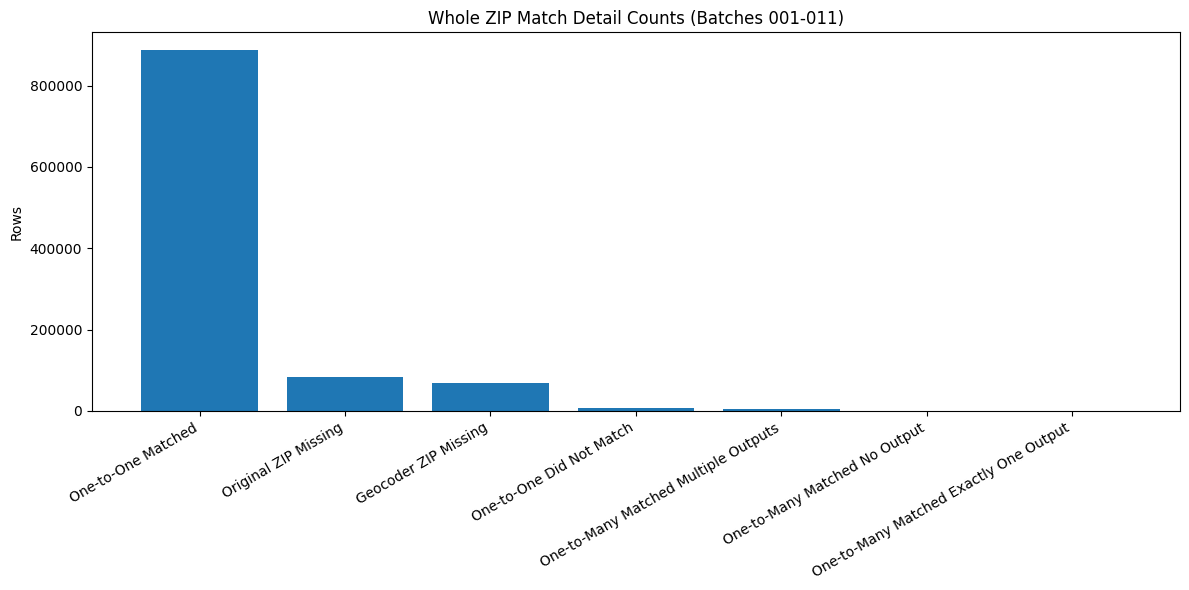

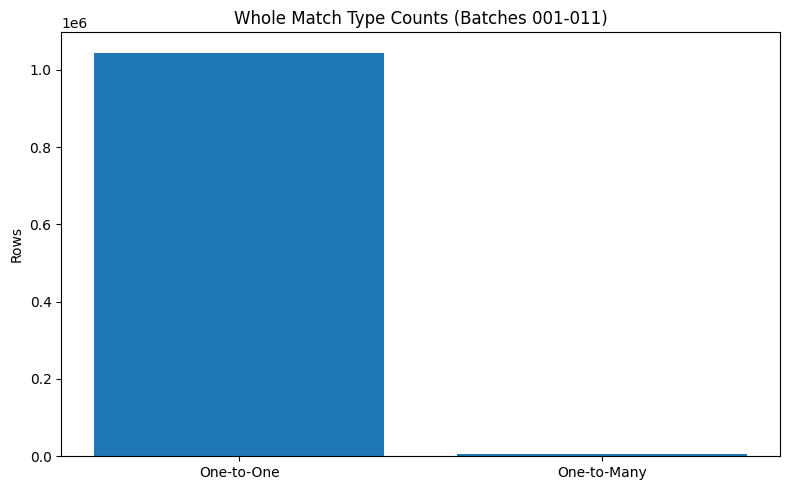

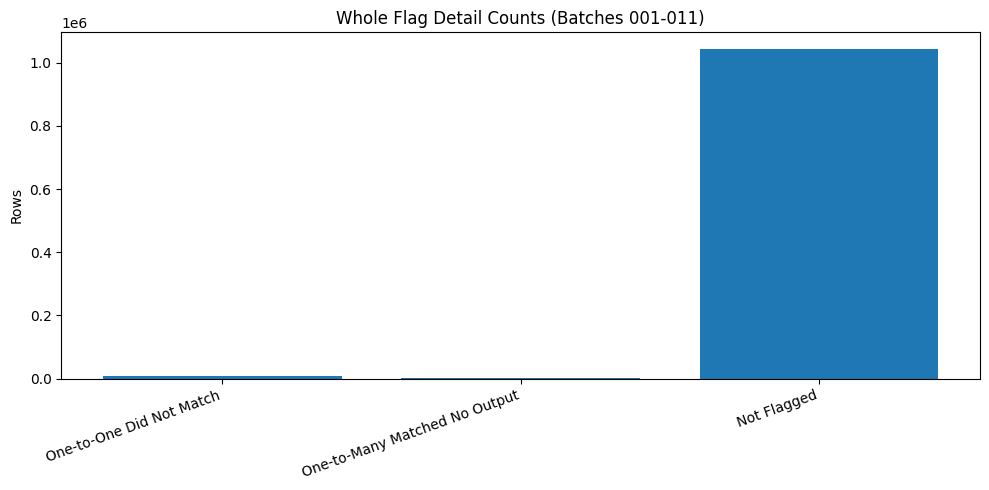

Saved figures:
../../output/2_analysis/figures\4_whole_zipcode_matcher_zip_detail_counts.png
../../output/2_analysis/figures\4_whole_zipcode_matcher_match_type_counts.png
../../output/2_analysis/figures\4_whole_zipcode_matcher_flag_counts.png


In [36]:
plot_status = status_counts.sort_values('rows', ascending=False).copy()
plot_flags = flag_counts.copy()
plot_flags['flag_detail'] = plot_flags['flag_detail'].fillna('Not Flagged')

plt.figure(figsize=(12, 6))
plt.bar(plot_status['zip_match_detail'], plot_status['rows'])
plt.xticks(rotation=30, ha='right')
plt.ylabel('Rows')
plt.title('Whole ZIP Match Detail Counts (Batches 001-011)')
plt.tight_layout()
fig1_path = os.path.join(FIGURES_OUT_DIR, '4_whole_zipcode_matcher_zip_detail_counts.png')
plt.savefig(fig1_path, dpi=150)
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(match_type_counts['match_type'], match_type_counts['rows'])
plt.ylabel('Rows')
plt.title('Whole Match Type Counts (Batches 001-011)')
plt.tight_layout()
fig2_path = os.path.join(FIGURES_OUT_DIR, '4_whole_zipcode_matcher_match_type_counts.png')
plt.savefig(fig2_path, dpi=150)
plt.show()

plt.figure(figsize=(10, 5))
plt.bar(plot_flags['flag_detail'], plot_flags['rows'])
plt.xticks(rotation=20, ha='right')
plt.ylabel('Rows')
plt.title('Whole Flag Detail Counts (Batches 001-011)')
plt.tight_layout()
fig3_path = os.path.join(FIGURES_OUT_DIR, '4_whole_zipcode_matcher_flag_counts.png')
plt.savefig(fig3_path, dpi=150)
plt.show()

print('Saved figures:')
print(fig1_path)
print(fig2_path)
print(fig3_path)

In [37]:
def estimate_rows_per_file(frame, max_bytes, sample_rows=20000, safety=0.9):
    n = len(frame)
    if n == 0:
        return 1
    sample_n = min(sample_rows, n)
    sample_csv_bytes = len(frame.head(sample_n).to_csv(index=False).encode('utf-8'))
    bytes_per_row = max(1.0, sample_csv_bytes / max(1, sample_n))
    return max(1, int((max_bytes / bytes_per_row) * safety))


def save_github_safe_csv_parts(frame, out_prefix, max_mb=95):
    max_bytes = int(max_mb * 1024 * 1024)
    n = len(frame)
    rows_per_file = estimate_rows_per_file(frame, max_bytes=max_bytes)

    part_paths = []
    manifest_rows = []
    part = 1
    start = 0

    while start < n:
        end = min(start + rows_per_file, n)
        path = f'{out_prefix}_{part:03d}.csv'
        chunk = frame.iloc[start:end]
        chunk.to_csv(path, index=False)
        size_bytes = os.path.getsize(path)

        if size_bytes > max_bytes and len(chunk) > 1:
            os.remove(path)
            rows_per_file = max(1, int((end - start) * 0.85))
            continue

        part_paths.append(path)
        manifest_rows.append({
            'part_file': os.path.basename(path),
            'rows': len(chunk),
            'size_mb': round(size_bytes / (1024 * 1024), 2),
            'start_row_1based': start + 1,
            'end_row_1based': end,
        })

        start = end
        part += 1

    manifest = pd.DataFrame(manifest_rows)
    return part_paths, manifest


def save_combined_prefer_single(frame, single_out_path, out_prefix, max_mb=95):
    max_bytes = int(max_mb * 1024 * 1024)

    frame.to_csv(single_out_path, index=False)
    single_size = os.path.getsize(single_out_path)

    if single_size <= max_bytes:
        manifest = pd.DataFrame([
            {
                'part_file': os.path.basename(single_out_path),
                'rows': len(frame),
                'size_mb': round(single_size / (1024 * 1024), 2),
                'start_row_1based': 1,
                'end_row_1based': len(frame),
            }
        ])
        return [single_out_path], manifest, True

    os.remove(single_out_path)
    part_paths, manifest = save_github_safe_csv_parts(frame, out_prefix, max_mb=max_mb)
    return part_paths, manifest, False


part_paths, manifest, used_single = save_combined_prefer_single(
    df,
    single_out_path=COMBINED_SINGLE_OUT_PATH,
    out_prefix=COMBINED_OUT_PREFIX,
    max_mb=GITHUB_MAX_MB,
)
manifest.to_csv(MANIFEST_OUT_PATH, index=False)

if used_single:
    print('Saved single combined derived dataframe (within GitHub size limit):')
else:
    print('Single file exceeded size limit; saved GitHub-safe split files:')
for p in part_paths:
    print(f'  - {p} ({os.path.getsize(p)/(1024*1024):.2f} MB)')
print(f'Manifest: {MANIFEST_OUT_PATH}')
print(f"Total rows saved: {manifest['rows'].sum():,}")

Single file exceeded size limit; saved GitHub-safe split files:
  - ../../data/1_derived\4_whole_zipcode_matcher_001.csv (84.86 MB)
  - ../../data/1_derived\4_whole_zipcode_matcher_002.csv (83.90 MB)
  - ../../data/1_derived\4_whole_zipcode_matcher_003.csv (84.24 MB)
  - ../../data/1_derived\4_whole_zipcode_matcher_004.csv (84.70 MB)
  - ../../data/1_derived\4_whole_zipcode_matcher_005.csv (82.98 MB)
  - ../../data/1_derived\4_whole_zipcode_matcher_006.csv (83.31 MB)
  - ../../data/1_derived\4_whole_zipcode_matcher_007.csv (0.81 MB)
Manifest: ../../data/1_derived\4_whole_zipcode_matcher_manifest.csv
Total rows saved: 1,051,219


In [38]:
df[[
    'PropertyId',
    'source_batch',
    'match',
    'match_type',
    'Address.PostalCode',
    'zip_original',
    'matched_address',
    'zip_geocoder_all_str',
    'tie_candidate_count',
    'matching_output_count',
    'zip_match_detail',
    'flag',
    'flag_detail',
    'final_lat',
    'final_long',
    'census_tract',
    'zipcode_match_status',
    'zipcode_match_bool',
]].head(20)

,PropertyId,source_batch,match,match_type,Address.PostalCode,zip_original,matched_address,zip_geocoder_all_str,tie_candidate_count,matching_output_count,zip_match_detail,flag,flag_detail,final_lat,final_long,census_tract,zipcode_match_status,zipcode_match_bool
0,435558.0,001,No_Match,One-to-One,30339.0,30339,NaN,None,0,0,Geocoder ZIP Missing,False,None,None,None,0.0,Geocoder Missing,False
1,445018.0,001,Match,One-to-One,30327.0,30327,"3200 DOWNWOOD CIR NW, ATLANTA, GA, 30327",30327,0,1,One-to-One Matched,False,None,33.840893,-84.426522,9803.0,Match,True
2,440921.0,001,Match,One-to-One,30303.0,30303,"100 EDGEWOOD AVE NE, ATLANTA, GA, 30303",30303,0,1,One-to-One Matched,False,None,33.754541,-84.386374,11901.0,Match,True
3,442552.0,001,Match,One-to-One,30318.0,30318,"1888 EMERY ST NW, ATLANTA, GA, 30318",30318,0,1,One-to-One Matched,False,None,33.807229,-84.414403,9001.0,Match,True
4,444958.0,001,Match,One-to-One,30326.0,30326,"3500 LENOX RD, ATLANTA, GA, 30326",30326,0,1,One-to-One Matched,False,None,33.848737,-84.360784,9606.0,Match,True
5,439920.0,001,Match,One-to-One,30317.0,30317,"1599A MEMORIAL DR SE, ATLANTA, GA, 30317",30317,0,1,One-to-One Matched,False,None,33.747454,-84.337185,20901.0,Match,True
6,439359.0,001,Match,One-to-One,30316.0,30316,"1234 MORELAND AVE SE, ATLANTA, GA, 30316",30316,0,1,One-to-One Matched,False,None,33.71893,-84.349403,23801.0,Match,True
7,441061.0,001,Match,One-to-One,30350.0,30350,"400 NORTHRIDGE RD, ATLANTA, GA, 30350",30350,0,1,One-to-One Matched,False,None,33.981851,-84.347232,10125.0,Match,True
8,442826.0,001,Match,One-to-One,30327.0,30327,"3715 NORTHSIDE PKWY NW, ATLANTA, GA, 30327",30327,0,1,One-to-One Matched,False,None,33.853984,-84.430978,9802.0,Match,True
9,5017002.0,001,Match,One-to-One,30312.0,30312,"300 OAKLAND AVE SE, ATLANTA, GA, 30312",30312,0,1,One-to-One Matched,False,None,33.745658,-84.374802,4900.0,Match,True
